> #### Environment Setup
> Copy the following line to the terminal
> ```cmd
> pip install matplotlib seaborn numpy scipy scikit-learn tensorflow yfinance
> ```

# Plan
1. Fetch Data
2. Generate All Candidate Features (technical indicators, returns, ratios, time)
3. Forward Selection — find the best feature subset
4. Data Preparation — selected features, train/test split **before** scaling, RobustScaler
5. Build & Train LSTM — two LSTM layers with Dropout, EarlyStopping
6. Predict & Visualize
7. Evaluate — RMSE, MAE, MAPE

---
# 1. Fetching Stock Data

In [27]:
import yfinance as yf

stock_data = yf.download('AAPL', start='2016-01-01', multi_level_index=False)
stock_data

[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2016-01-04,23.730949,23.735456,22.976335,23.113742,270597600
2016-01-05,23.136267,23.843577,23.068690,23.821052,223164000
2016-01-06,22.683496,23.059679,22.496534,22.651960,273829600
2016-01-07,21.726151,22.555101,21.721646,22.228477,324377600
2016-01-08,21.841030,22.325335,21.795979,22.199191,283192000
...,...,...,...,...,...
2026-04-06,258.859985,262.160004,256.459991,256.510010,29329900
2026-04-07,253.500000,256.200012,245.699997,256.160004,62148000
2026-04-08,258.899994,259.750000,256.529999,258.450012,41032800


---
# 2. Generate All Candidate Features

In [28]:
import numpy as np
import pandas as pd
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

df = stock_data.copy()

# --- Technical indicators ---
for w in [5, 10, 20, 50]:
    df[f'SMA_{w}']    = df['Close'].rolling(w).mean()
    df[f'EMA_{w}']    = df['Close'].ewm(span=w).mean()
    df[f'Volatility_{w}'] = df['Close'].pct_change().rolling(w).std()

df['RSI_14'] = 100 - 100 / (1 + df['Close'].diff().clip(lower=0).rolling(14).mean() /
                             df['Close'].diff().clip(upper=0).abs().rolling(14).mean())

ema12 = df['Close'].ewm(span=12).mean()
ema26 = df['Close'].ewm(span=26).mean()
df['MACD']         = ema12 - ema26
df['MACD_signal']  = df['MACD'].ewm(span=9).mean()
df['MACD_hist']    = df['MACD'] - df['MACD_signal']

sma20 = df['Close'].rolling(20).mean()
std20 = df['Close'].rolling(20).std()
df['BB_upper'] = sma20 + 2 * std20
df['BB_lower'] = sma20 - 2 * std20
df['BB_width'] = (df['BB_upper'] - df['BB_lower']) / sma20

high_low  = df['High'] - df['Low']
high_prev = (df['High'] - df['Close'].shift(1)).abs()
low_prev  = (df['Low']  - df['Close'].shift(1)).abs()
df['ATR_14'] = pd.concat([high_low, high_prev, low_prev], axis=1).max(axis=1).rolling(14).mean()

df['OBV'] = (np.sign(df['Close'].diff()) * df['Volume']).cumsum()

# --- Returns ---
df['log_return']   = np.log(df['Close'] / df['Close'].shift(1))
df['return_1d']    = df['Close'].pct_change()
df['return_5d']    = df['Close'].pct_change(5)

# --- Price ratios ---
df['high_low_ratio']  = df['High'] / df['Low']
df['close_open_ratio'] = df['Close'] / df['Open']

# --- Time features ---
# Year
year_days = df.index.is_leap_year * 366 + (~df.index.is_leap_year) * 365
df['sin_year'] = np.sin(2 * np.pi * (df.index.dayofyear - 1) / year_days)
df['cos_year'] = np.cos(2 * np.pi * (df.index.dayofyear - 1) / year_days)
df['day_of_week'] = df.index.dayofweek / 6.0

# Week (52 weeks)
df['sin_week'] = np.sin(2 * np.pi * (df.index.isocalendar().week - 1) / 52)
df['cos_week'] = np.cos(2 * np.pi * (df.index.isocalendar().week - 1) / 52)

# Month (12 months)
df['sin_month'] = np.sin(2 * np.pi * (df.index.month - 1) / 12)
df['cos_month'] = np.cos(2 * np.pi * (df.index.month - 1) / 12)

# Quarter (4 quarters)
df['sin_quarter'] = np.sin(2 * np.pi * (df.index.quarter - 1) / 4)
df['cos_quarter'] = np.cos(2 * np.pi * (df.index.quarter - 1) / 4)

# --- Target ---
df['Close_nxt'] = df['Close'].shift(-1)
df = df.dropna()

ALL_FEATURES = [c for c in df.columns if c not in ['Close_nxt']]
print(f"{len(ALL_FEATURES)} candidate features:\n{ALL_FEATURES}")

40 candidate features:
['Close', 'High', 'Low', 'Open', 'Volume', 'SMA_5', 'EMA_5', 'Volatility_5', 'SMA_10', 'EMA_10', 'Volatility_10', 'SMA_20', 'EMA_20', 'Volatility_20', 'SMA_50', 'EMA_50', 'Volatility_50', 'RSI_14', 'MACD', 'MACD_signal', 'MACD_hist', 'BB_upper', 'BB_lower', 'BB_width', 'ATR_14', 'OBV', 'log_return', 'return_1d', 'return_5d', 'high_low_ratio', 'close_open_ratio', 'sin_year', 'cos_year', 'day_of_week', 'sin_week', 'cos_week', 'sin_month', 'cos_month', 'sin_quarter', 'cos_quarter']


In [29]:
df.to_csv('data/stock_data_AAPL.csv')

---
# 3. Feature Selection
Pearson Correlation Filtering and LASSO

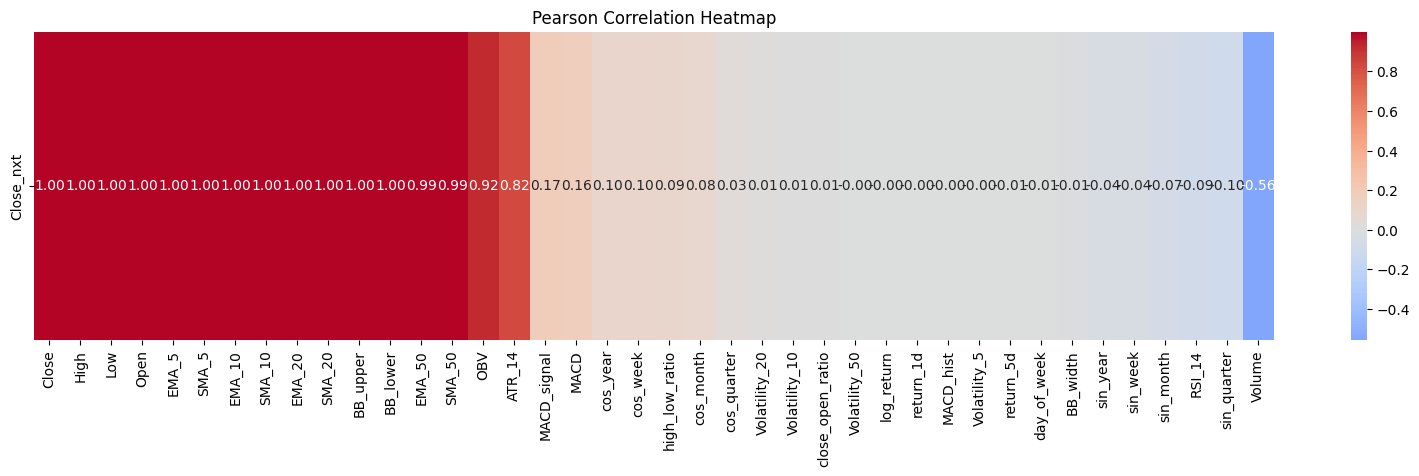

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# -------- PEARSON CORRELATION VISUALIZATION -------
target_col   = ['Close_nxt']
feature_cols = list(set(df.columns) - set(target_col))

# Compute correlations with the target
corr_matrix = df[feature_cols + target_col].corr(method='pearson')
corr_matrix = corr_matrix[target_col].drop(target_col).sort_values(by=target_col[0], ascending=False).transpose()
plt.figure(figsize=(20, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title("Pearson Correlation Heatmap")
plt.show()


In [31]:
# ----------- DROPING NEAR ZERO CORRELATION---------------
feature_cols = set(corr_matrix.columns[abs(corr_matrix.loc['Close_nxt']) > 0.01])
pd.DataFrame(feature_cols)

,0
0,RSI_14
1,MACD_signal
2,Volatility_20
3,EMA_10
4,OBV
5,Volume
6,cos_year
7,Close
8,SMA_20
9,SMA_5


In [ ]:
from sklearn.linear_model import LassoCV
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import RobustScaler

# Prepare data (using only features, not target)
X = df[list(feature_cols)].values
y = df[target_col].values

# Split BEFORE scaling to prevent data leakage
sample_len = int(len(X)*0.2)
X_sample = X[:sample_len]
y_sample = y[:sample_len]

print(X_sample.shape, y_sample.shape)

# Scale features (separate scaler for train/test)
scaler = RobustScaler()
X_sample_scaled = scaler.fit_transform(X_sample)

# ============ Feature SELECTION ======================

# Tune and train a simple LASSO model _________________

lasso = LassoCV(
    alphas=np.logspace(-4, 4, 100),
    max_iter=100000,
    tol=1e-3,                               # Loosen tolerance
    cv=5,
)
lasso.fit(X_sample_scaled, y_sample.ravel())

lasso_selector = SelectFromModel(lasso, prefit=True)
lasso_mask = lasso_selector.get_support()
print('Lasso Selected: ', lasso_mask.sum())

# Get selected features (non-zero coefficients)
selected_mask = lasso.coef_ != 0
selected_features = np.array(list(feature_cols))[selected_mask].tolist()

print(f'LASSO selected {len(selected_features)} features:')
print(pd.DataFrame(selected_features))


(506, 31) (506, 1)
Lasso Selected:  12
LASSO selected 12 features:
                0
0          RSI_14
1     MACD_signal
2   Volatility_20
3          EMA_10
4             OBV
5          Volume
6           Close
7     cos_quarter
8          ATR_14
9        BB_width
10           MACD
11    sin_quarter


---
# 4. Data Preparation (using selected features)
Split **before** scaling to prevent data leakage. Use separate scalers for input features and the target column.

In [34]:
from sklearn.preprocessing import RobustScaler
LOOKBACK = 60
TRAIN_RATIO = 0.8
SEL_EPOCHS = 50
SEL_PATIENCE = 8

feature_cols = selected_features          # from forward selection above

split_idx = int(len(df) * TRAIN_RATIO)

train_features_raw = df[feature_cols].values[:split_idx]
test_features_raw  = df[feature_cols].values[split_idx:]
train_target_raw   = df[target_col].values[:split_idx]
test_target_raw    = df[target_col].values[split_idx:]

scaler = RobustScaler()
target_scaler  = RobustScaler()

train_features = scaler.fit_transform(train_features_raw)
test_features  = scaler.transform(test_features_raw)
train_target   = target_scaler.fit_transform(train_target_raw)
test_target    = target_scaler.transform(test_target_raw)

print(f'Feature columns ({len(feature_cols)}): {feature_cols}')
print(f'Train: {train_features.shape}  Test: {test_features.shape}')

Feature columns (12): ['RSI_14', 'MACD_signal', 'Volatility_20', 'EMA_10', 'OBV', 'Volume', 'Close', 'cos_quarter', 'ATR_14', 'BB_width', 'MACD', 'sin_quarter']
Train: (2024, 12)  Test: (507, 12)


In [35]:
def create_sequences(features, target, lookback):
    X, y = [], []
    for i in range(lookback, len(features)):
        X.append(features[i - lookback:i])
        y.append(target[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_features, train_target, LOOKBACK)

test_features_padded = np.concatenate([train_features[-LOOKBACK:], test_features])
test_target_padded   = np.concatenate([train_target[-LOOKBACK:], test_target])
X_test, y_test = create_sequences(test_features_padded, test_target_padded, LOOKBACK)

print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_test : {X_test.shape}  y_test : {y_test.shape}')

X_train: (1964, 60, 12)  y_train: (1964,)
X_test : (507, 60, 12)  y_test : (507,)


---
# 5. Building and Training LSTM

In [36]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Input
from keras.callbacks import EarlyStopping

model = Sequential([
    Input(shape=(LOOKBACK, X_train.shape[2])),
    LSTM(100, return_sequences=True),
    Dropout(0.2),
    LSTM(100, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 100)        │        45,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125,701 (491.02 KB)

 Trainable params: 125,701 (491.02 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 77ms/step - loss: 0.0234 - mae: 0.1015 - val_loss: 0.0183 - val_mae: 0.1079
Epoch 2/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - loss: 0.0053 - mae: 0.0555 - val_loss: 0.0129 - val_mae: 0.0946
Epoch 3/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - loss: 0.0048 - mae: 0.0525 - val_loss: 0.0076 - val_mae: 0.0672
Epoch 4/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - loss: 0.0039 - mae: 0.0471 - val_loss: 0.0063 - val_mae: 0.0624
Epoch 5/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - loss: 0.0037 - mae: 0.0459 - val_loss: 0.0047 - val_mae: 0.0542
Epoch 6/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - loss: 0.0033 - mae: 0.0446 - val_loss: 0.0058 - val_mae: 0.0578
Epoch 7/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - loss: 0.0033 - mae: 0.0434 - val_loss: 0.0055 - val_mae: 0.0574
Epoch 8/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step - loss: 0.0031 - mae: 0.0421 - val_loss: 0.0073 - val_mae: 0.0676
Epoch 9/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - lo

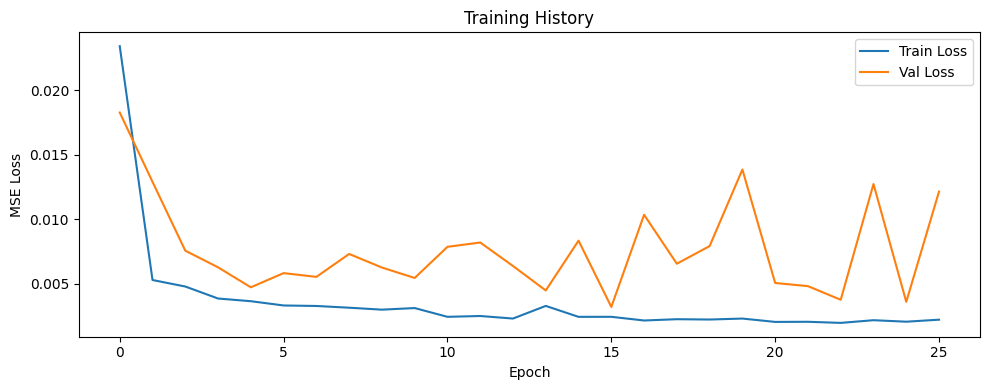

In [38]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training History')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

---
# 6. Making Predictions

In [39]:
pred_scaled = model.predict(X_test)

prediction = target_scaler.inverse_transform(pred_scaled)
y_test_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1))

print(f'Predictions shape: {prediction.shape}')
print(f'Actuals shape     : {y_test_actual.shape}')

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step
Predictions shape: (507, 1)
Actuals shape     : (507, 1)


---
# 7. Visualisation

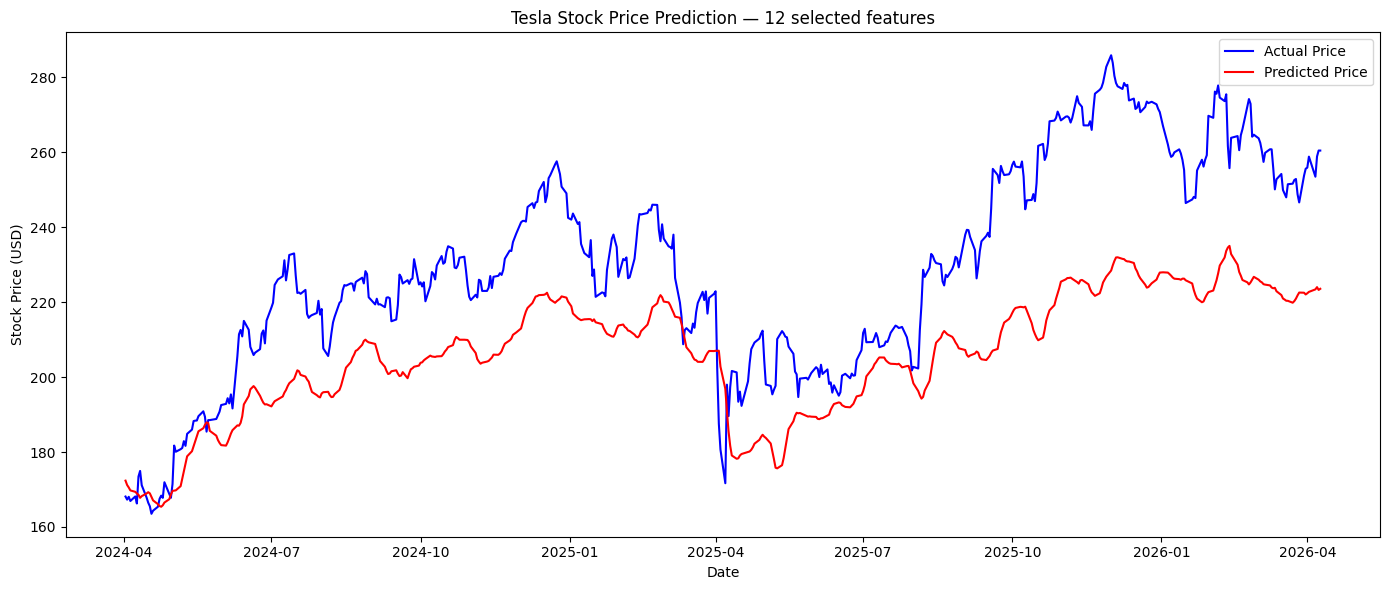

In [41]:
test_dates = df.index[split_idx:]

plt.figure(figsize=(14, 6))
plt.plot(test_dates, y_test_actual.flatten(), label='Actual Price', color='blue')
plt.plot(test_dates, prediction.flatten(), label='Predicted Price', color='red')
plt.title(f'Tesla Stock Price Prediction — {len(selected_features)} selected features')
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

---
# 8. Model Evaluation

In [42]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse  = mean_squared_error(y_test_actual, prediction)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test_actual, prediction)
mape = np.mean(np.abs((y_test_actual - prediction) / y_test_actual)) * 100

print('=' * 55)
print(f'LSTM with Forward-Selected Features ({len(feature_cols)})')
print(f'Features: {feature_cols}')
print('=' * 55)
print(f'  MSE  : {mse:.4f}')
print(f'  RMSE : {rmse:.4f}')
print(f'  MAE  : {mae:.4f}')
print(f'  MAPE : {mape:.2f}%')
print('=' * 55)

LSTM with Forward-Selected Features (12)
Features: ['RSI_14', 'MACD_signal', 'Volatility_20', 'EMA_10', 'OBV', 'Volume', 'Close', 'cos_quarter', 'ATR_14', 'BB_width', 'MACD', 'sin_quarter']
  MSE  : 731.8476
  RMSE : 27.0527
  MAE  : 23.4953
  MAPE : 9.78%


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


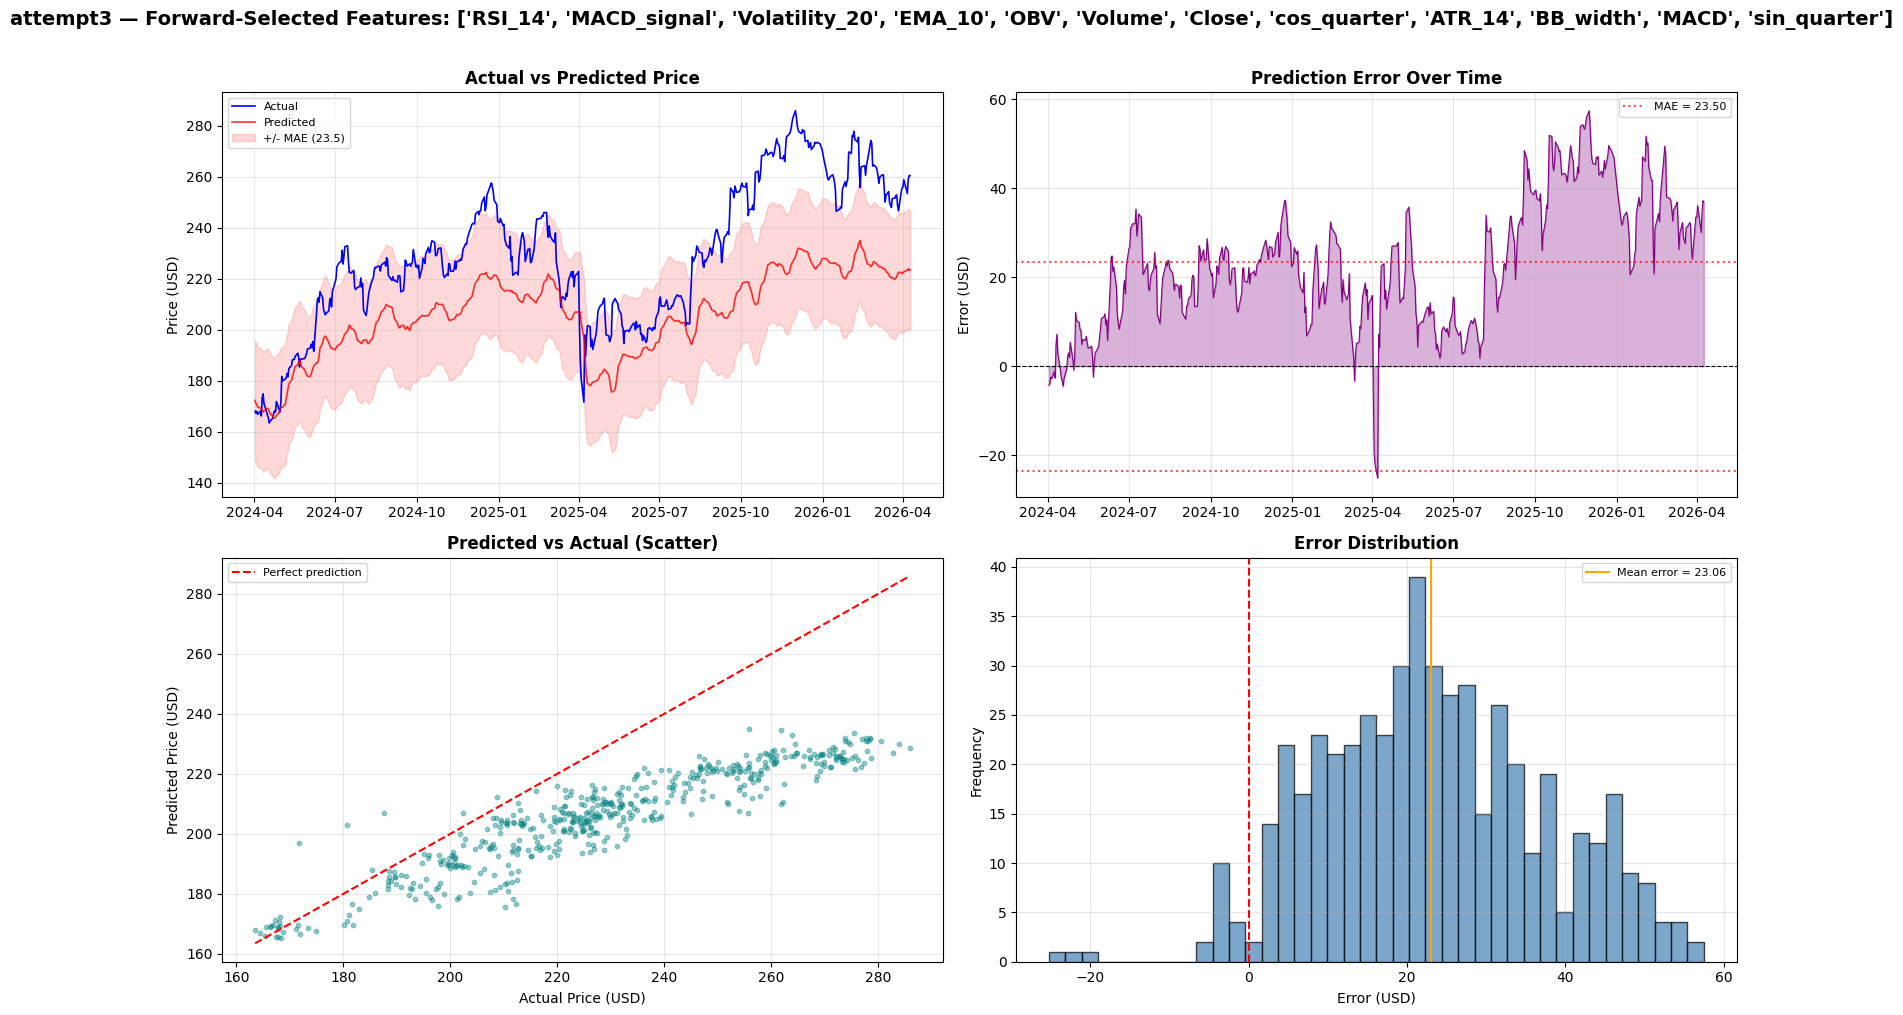

Mean Error: 23.0578  |  Std Error: 14.1486
Max Over-prediction: 57.4735  |  Max Under-prediction: -25.1964
Mean Abs % Error: 9.78%


In [43]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

pred_scaled = model.predict(X_test)
prediction = target_scaler.inverse_transform(pred_scaled)
y_test_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1))
test_dates = df.index[split_idx:]

mse  = mean_squared_error(y_test_actual, prediction)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test_actual, prediction)
mape = np.mean(np.abs((y_test_actual - prediction) / y_test_actual)) * 100

errors = y_test_actual.flatten() - prediction.flatten()
pct_errors = (errors / y_test_actual.flatten()) * 100

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax = axes[0, 0]
ax.plot(test_dates, y_test_actual.flatten(), label='Actual', color='blue', linewidth=1.2)
ax.plot(test_dates, prediction.flatten(), label='Predicted', color='red', linewidth=1.2, alpha=0.8)
ax.fill_between(test_dates, prediction.flatten() - mae, prediction.flatten() + mae,
                alpha=0.15, color='red', label=f'+/- MAE ({mae:.1f})')
ax.set_title('Actual vs Predicted Price', fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(test_dates, errors, color='purple', linewidth=0.8)
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax.axhline(y=mae, color='red', linestyle=':', alpha=0.7, label=f'MAE = {mae:.2f}')
ax.axhline(y=-mae, color='red', linestyle=':', alpha=0.7)
ax.fill_between(test_dates, errors, 0, alpha=0.3, color='purple')
ax.set_title('Prediction Error Over Time', fontweight='bold')
ax.set_ylabel('Error (USD)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.scatter(y_test_actual.flatten(), prediction.flatten(), alpha=0.4, s=10, color='teal')
min_val = min(y_test_actual.min(), prediction.min())
max_val = max(y_test_actual.max(), prediction.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Price (USD)')
ax.set_ylabel('Predicted Price (USD)')
ax.set_title('Predicted vs Actual (Scatter)', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.hist(errors, bins=40, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5)
ax.axvline(x=errors.mean(), color='orange', linestyle='-', linewidth=1.5,
           label=f'Mean error = {errors.mean():.2f}')
ax.set_xlabel('Error (USD)')
ax.set_ylabel('Frequency')
ax.set_title('Error Distribution', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.suptitle(f'attempt3 — Forward-Selected Features: {feature_cols}', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Mean Error: {errors.mean():.4f}  |  Std Error: {errors.std():.4f}')
print(f'Max Over-prediction: {errors.max():.4f}  |  Max Under-prediction: {errors.min():.4f}')
print(f'Mean Abs % Error: {np.abs(pct_errors).mean():.2f}%')